### Customer retention is a key challenge in the banking industry
Focusing on predicting customer churn—whether a customer is likely to leave the bank—using demographic, account, and behavioral information.

Participants are tasked with building a binary classification model to predict the target variable Exited, where:

1 = Customer churned (left the bank)

0 = Customer remained with the bank

### Evaluation
Submissions will be evaluated using "Accuracy".

Accuracy measures the proportion of correctly classified customers and is calculated as:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

#### import library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score


In [3]:
torch.manual_seed(42)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cpu


In [4]:
# Load the dataset
data = pd.read_csv("train.csv")
test_data = pd.read_csv("test_without_labels.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,3888,15769110,Stehle,653,France,Female,46,5,0.00,2,1,0,49707.85,0
1,6618,15700826,Ko,678,Germany,Female,54,1,123699.28,2,0,1,105221.76,0
2,6622,15710365,Thomson,646,France,Male,50,0,104129.24,2,1,0,181794.86,1
3,6627,15619932,Lombardi,847,France,Male,66,7,123760.68,1,0,1,53157.16,0
4,8353,15641413,Crawford,587,Germany,Female,49,7,155393.98,2,1,0,13308.20,1


In [5]:
# shape of the dataset
print(f"Shape of the dataset: {data.shape}")

Shape of the dataset: (7000, 14)


### preprocessing the data

In [6]:
# drop the 'RowNumber', 'Surname' column as it is not useful for prediction
data = data.drop(['RowNumber', 'Surname'], axis=1)
test_data_pre = test_data.drop(['RowNumber', 'Surname'], axis=1)

In [7]:
# one-hot encode categorical variables
data = pd.get_dummies(data, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
test_data_pre = pd.get_dummies(test_data_pre, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
data.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,15769110,653,46,5,0.00,2,1,0,49707.85,0,0,0,0
1,15700826,678,54,1,123699.28,2,0,1,105221.76,0,1,0,0
2,15710365,646,50,0,104129.24,2,1,0,181794.86,1,0,0,1
3,15619932,847,66,7,123760.68,1,0,1,53157.16,0,0,0,1
4,15641413,587,49,7,155393.98,2,1,0,13308.20,1,1,0,0


In [8]:
# correlation matrix
correlation_matrix = data.corr()
correlation_matrix["Exited"].sort_values(ascending=False)

Exited               1.000000
Age                  0.375804
Geography_Germany    0.320158
Balance              0.237334
EstimatedSalary      0.018328
HasCrCard            0.006205
CustomerId          -0.005307
Tenure              -0.063052
Gender_Male         -0.093804
Geography_Spain     -0.097803
CreditScore         -0.108203
NumOfProducts       -0.190115
IsActiveMember      -0.404305
Name: Exited, dtype: float64

we see that 'HasCrCard' and 'CustomerId' are not useful for prediction, so we will drop them also.

In [9]:
# drop the 'HasCrCard' and 'CustomerId' columns as they are not useful for prediction
data = data.drop(['HasCrCard', 'CustomerId'], axis=1)
test_data_pre = test_data_pre.drop(['HasCrCard', 'CustomerId'], axis=1)
data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,653,46,5,0.00,2,0,49707.85,0,0,0,0
1,678,54,1,123699.28,2,1,105221.76,0,1,0,0
2,646,50,0,104129.24,2,0,181794.86,1,0,0,1
3,847,66,7,123760.68,1,1,53157.16,0,0,0,1
4,587,49,7,155393.98,2,0,13308.20,1,1,0,0


In [10]:
# split the dataset into training and validation sets
feature_cols = data.drop('Exited', axis=1).columns
X = data[feature_cols].values
y = data['Exited'].values

# scale the features using Min-Max scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
test_data_pre = scaler.transform(test_data_pre[feature_cols].values)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")


Train shape: (5600, 10), Validation shape: (1400, 10)


### Building a predictive model (NN with Torch)

In [11]:
# initialize the features and target variable to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(device)

X_train_tensor.shape, X_val_tensor.shape, y_train_tensor.shape, y_val_tensor.shape

(torch.Size([5600, 10]),
 torch.Size([1400, 10]),
 torch.Size([5600]),
 torch.Size([1400]))

In [12]:
# Custom Dataset class for our bank customers data
class BankCustomersDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = BankCustomersDataset(X_train_tensor, y_train_tensor)
val_dataset = BankCustomersDataset(X_val_tensor, y_val_tensor)
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
print(f"Sample train data: {train_dataset[0]}")

Train samples: 5600, Validation samples: 1400
Sample train data: (tensor([0.5480, 0.4865, 0.3000, 0.4896, 0.0000, 0.0000, 0.5525, 1.0000, 0.0000,
        1.0000]), tensor(1.))


In [13]:
# data loaders
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)
for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
    print(f"Batch {batch_idx + 1}:")
    print(f"X_batch shape: {X_batch.shape}")
    print(f"y_batch shape: {y_batch.shape}")
    break

Batch 1:
X_batch shape: torch.Size([32, 10])
y_batch shape: torch.Size([32])


In [ ]:
# building NN class
class BankCustomerNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            # nn.ReLU(),
            # nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            # nn.Sigmoid()  # output layer with sigmoid activation for binary classification
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # returns logits

model = BankCustomerNN(input_dim=X_train_tensor.shape[1]).to(device)


In [38]:
# training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, device=device):
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    val_precision_history = []
    val_recall_history = []
    val_f1_history = []
    val_auc_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_loss_history.append(train_loss)

        model.eval()
        val_running_loss = 0.0
        val_probs = []
        val_labels = []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), labels)
                val_running_loss += loss.item()
                val_probs.extend(torch.sigmoid(outputs).cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / len(val_loader)
        val_loss_history.append(val_loss)

        val_probs = np.array(val_probs)
        val_labels = np.array(val_labels)
        val_preds = (val_probs >= 0.5).astype(int)

        val_acc = accuracy_score(val_labels, val_preds)
        val_precision = precision_score(val_labels, val_preds, zero_division=0)
        val_recall = recall_score(val_labels, val_preds, zero_division=0)
        val_f1 = f1_score(val_labels, val_preds, zero_division=0)
        val_auc = roc_auc_score(val_labels, val_probs)

        val_acc_history.append(val_acc)
        val_precision_history.append(val_precision)
        val_recall_history.append(val_recall)
        val_f1_history.append(val_f1)
        val_auc_history.append(val_auc)

        print(
            f"Epoch [{epoch + 1}/{epochs}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            # f" val_precision={val_precision:.4f} "
            # f"val_recall={val_recall:.4f} val_f1={val_f1:.4f} val_auc={val_auc:.4f}"
        )

    return {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'val_acc': val_acc_history,
        'val_precision': val_precision_history,
        'val_recall': val_recall_history,
        'val_f1': val_f1_history,
        'val_auc': val_auc_history,
    }


Training the model...
Epoch [1/25] train_loss=0.3073 val_loss=0.1962 val_acc=0.9300
Epoch [2/25] train_loss=0.2018 val_loss=0.2080 val_acc=0.9236
Epoch [3/25] train_loss=0.1895 val_loss=0.1965 val_acc=0.9257
Epoch [4/25] train_loss=0.1631 val_loss=0.1322 val_acc=0.9464
Epoch [5/25] train_loss=0.1340 val_loss=0.1040 val_acc=0.9600
Epoch [6/25] train_loss=0.1102 val_loss=0.0970 val_acc=0.9636
Epoch [7/25] train_loss=0.1073 val_loss=0.0945 val_acc=0.9564
Epoch [8/25] train_loss=0.1031 val_loss=0.0924 val_acc=0.9671
Epoch [9/25] train_loss=0.0998 val_loss=0.1053 val_acc=0.9564
Epoch [10/25] train_loss=0.1005 val_loss=0.0964 val_acc=0.9564
Epoch [11/25] train_loss=0.1017 val_loss=0.0819 val_acc=0.9671
Epoch [12/25] train_loss=0.0990 val_loss=0.1027 val_acc=0.9521
Epoch [13/25] train_loss=0.0957 val_loss=0.0857 val_acc=0.9643
Epoch [14/25] train_loss=0.0955 val_loss=0.0872 val_acc=0.9564
Epoch [15/25] train_loss=0.0947 val_loss=0.0808 val_acc=0.9629
Epoch [16/25] train_loss=0.0978 val_loss=0

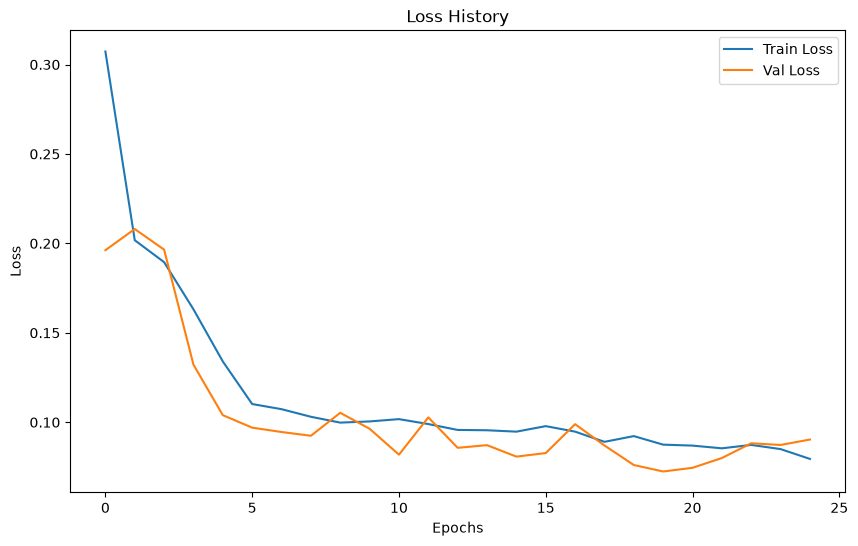

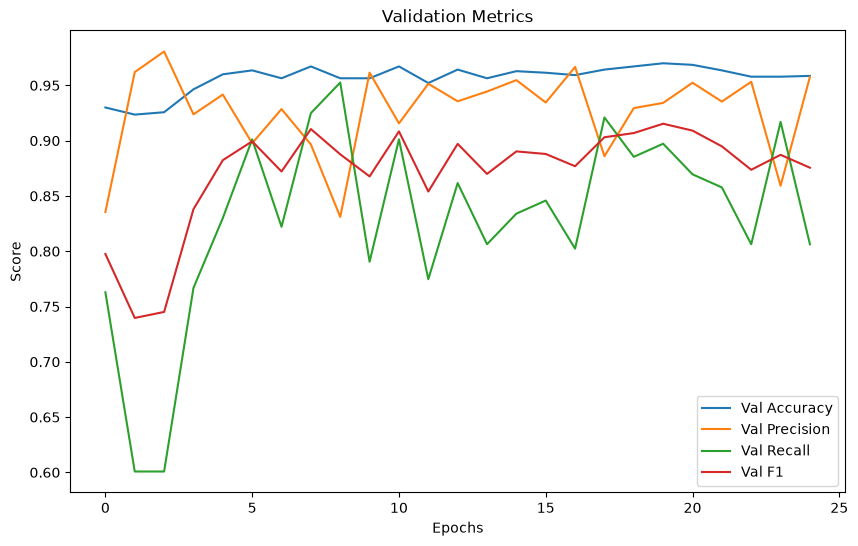

In [39]:
# selecting the optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()
print("Training the model...")
metrics = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=25,
)
# Visualizing the loss history
plt.plot(metrics['train_loss'], label="Train Loss")
plt.plot(metrics['val_loss'], label="Val Loss")
plt.title("Loss History")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(metrics['val_acc'], label="Val Accuracy")
plt.plot(metrics['val_precision'], label="Val Precision")
plt.plot(metrics['val_recall'], label="Val Recall")
plt.plot(metrics['val_f1'], label="Val F1")
plt.title("Validation Metrics")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.legend()
plt.show()


In [40]:
# Evaluate the model on the validation data
model.eval()
with torch.no_grad():
    logits = model(X_val_tensor)
    probs = torch.sigmoid(logits)
    y_pred_class = (probs >= 0.5).int()
# Accuracy
accuracy = accuracy_score(y_val_tensor.cpu(), y_pred_class.cpu())
classification = classification_report(y_val_tensor.cpu(), y_pred_class.cpu())

# print the results
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Classification Report:\n{classification}")


Validation Accuracy: 0.9586
Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      1147
         1.0       0.96      0.81      0.88       253

    accuracy                           0.96      1400
   macro avg       0.96      0.90      0.93      1400
weighted avg       0.96      0.96      0.96      1400



### Testing the model

In [41]:
# testing the model and saving the predictions to a CSV file
test_tensor = torch.tensor(test_data_pre, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    logits = model(test_tensor)
    probs = torch.sigmoid(logits)

test_predictions = (probs >= 0.5).int()
submission = pd.DataFrame({'id': np.arange(len(test_data)), 'Exited': test_predictions.cpu().numpy().flatten()})
submission.to_csv("submission.csv", index=False)
print(f"Submission saved to submission.csv")


Submission saved to submission.csv
